In [2]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
url = "https://raw.githubusercontent.com/guille1006/TFM/refs/heads/main/data/raw_data.csv"
df = pd.read_csv(url)

In [49]:
df_copy = df.copy()

In [50]:
# Columnas que no son necesarias para la limpieza de datos inicial
cols_to_drop = [
    'url', 'externalReference', 'thumbnail', 'propertyCode', 'externalReference',
    'description', 'suggestedTexts.title', 'suggestedTexts.subtitle',
    'notes', 'address', 'country', 'province', 'operation', 'priceInfo.price.currencySuffix',
    'topNewDevelopment', 'latitude', 'longitude'
]

df_copy.drop(columns=cols_to_drop, inplace=True)

column_tot = len(df_copy.columns)

# Voy a realizar un estudio de las variables y del tipo de estas
info_types = pd.DataFrame(
    {"Tipo de columna": df_copy.dtypes, "Valores únicos": df_copy.nunique(dropna=False)}
)

info_types

,Tipo de columna,Valores únicos
bathrooms,int64,18
detailedType.subTypology,object,14
detailedType.typology,object,3
district,object,271
exterior,object,3
floor,object,41
has360,bool,2
has3DTour,bool,2
hasLift,object,3
hasPlan,bool,2


In [51]:
def tabla_valores_unicos(df):
    df_frec = pd.DataFrame()

    for col in df.columns:
        # Puesto que al hacer groupby, los elementos que sean NaN no pertencen a ningun grupo, 
        # generare, solo para la visualización que estos elementos se llamen "Nulo"
        series_fillna = df[col].fillna("Nulo")

        # 
        series_cont = series_fillna.value_counts()
        series_frec = series_cont/series_cont.sum()

        #
        arrays_multiindex = [[col]* len(series_cont), series_cont.index.tolist()]
        multi_index = pd.MultiIndex.from_arrays(arrays_multiindex)

        result = pd.DataFrame({"n":series_cont.values, "%": series_frec.values}, index=multi_index)
        df_frec = pd.concat([df_frec, result], axis=0)
    
    return df_frec

In [52]:
mask = info_types["Valores únicos"][info_types["Valores únicos"] < 25].index


df_frec = tabla_valores_unicos(df_copy[mask])


# Diferenciacion de variables

## Varriables con valores nulos

In [53]:
df_nulls = (
    df_copy.isnull().sum()
    .to_frame(name="Nulos")
    .query("Nulos > 0")
    .assign(
        Valores_unicos = df_copy.nunique(dropna=False)
    )
    .assign(
        Tipo_columna = df_copy.dtypes
    )
    .sort_values(by="Nulos", ascending=False)
    .reset_index()
    .rename(columns={"index": "Columna"})
)

display(df_nulls)

,Columna,Nulos,Valores_unicos,Tipo_columna
0,parkingSpace.parkingSpacePrice,17192,58,float64
1,priceInfo.price.priceDropInfo.formerPrice,15687,635,float64
2,priceInfo.price.priceDropInfo.priceDropPercentage,15687,25,float64
3,priceInfo.price.priceDropInfo.priceDropValue,15687,220,float64
4,newDevelopmentFinished,15678,3,object
5,detailedType.subTypology,11193,14,object
6,highlight.groupDescription,10813,4,object
7,parkingSpace.hasParkingSpace,9617,2,object
8,parkingSpace.isParkingSpaceIncludedInPrice,9617,3,object
9,neighborhood,6979,196,object


In [54]:
variables_nulas = list(df_nulls["Columna"])

# Para quitar en los siguientes puntos las columnas con nulos de las demas columnas usaremos la siguiente funcion
def remove_repeated(list1, list2):
    return [x for x in list1 if x not in list2]

In [55]:
variables_nulas

['parkingSpace.parkingSpacePrice',
 'priceInfo.price.priceDropInfo.formerPrice',
 'priceInfo.price.priceDropInfo.priceDropPercentage',
 'priceInfo.price.priceDropInfo.priceDropValue',
 'newDevelopmentFinished',
 'detailedType.subTypology',
 'highlight.groupDescription',
 'parkingSpace.hasParkingSpace',
 'parkingSpace.isParkingSpaceIncludedInPrice',
 'neighborhood',
 'floor',
 'exterior',
 'hasLift',
 'district',
 'status']

## Variables booleanas

In [ ]:
# Primero vamos a analizar las variables dicotomicas, puesto que son las mas sencillas. Ademas usaremos en principio solo las 
# que no tengan valores nulos
variable_bool = info_types[info_types["Valores únicos"]<3].index.to_list()

# Una de ellas tiene valores nulos, por lo que en principio no la voy a catalogar como dicotomica
variable_bool = remove_repeated(variable_bool, variables_nulas)


In [57]:
variable_bool

['has360',
 'has3DTour',
 'hasPlan',
 'hasStaging',
 'hasVideo',
 'newDevelopment',
 'showAddress',
 'topPlus']

## Variables numericas

In [58]:
# Ahora vamos a extraer las variables numericas y ver si falta algo
variables_num = df_copy.select_dtypes(include=["number"]).columns.tolist()
variables_num = remove_repeated(variables_num, variables_nulas)
variables_num

['bathrooms',
 'numPhotos',
 'price',
 'priceByArea',
 'priceInfo.price.amount',
 'rooms',
 'size']

In [59]:
for var in variables_num:
    show = df_copy.sort_values(by=var)
    print(var)
    print(show[var].head(25))

bathrooms
9404     0
13604    0
4787     0
15691    0
3351     0
17305    0
13254    0
13683    0
16122    0
16175    0
8807     0
5078     0
11622    0
17193    0
10147    0
16341    0
17187    0
17186    0
15437    0
17110    0
3592     0
1305     0
16693    0
15251    0
2248     0
Name: bathrooms, dtype: int64
numPhotos
17249    0
17319    0
17320    0
6391     0
17321    0
17322    0
17323    0
17248    0
17247    0
17003    0
17324    0
17325    0
17326    0
17246    0
17327    0
17328    0
17250    0
17251    0
17252    0
17253    0
17309    0
17310    0
2468     0
17311    0
17312    0
Name: numPhotos, dtype: int64
price
16706    11000.0
16753    19000.0
17127    19000.0
16122    20000.0
16730    28500.0
14954    29500.0
16047    32000.0
9404     36000.0
16072    37000.0
4056     39900.0
16333    40000.0
15087    43500.0
15483    44000.0
16113    44000.0
6409     45000.0
17066    45000.0
5043     49000.0
16271    49000.0
16832    50000.0
16681    52400.0
12615    53400.0
17409  

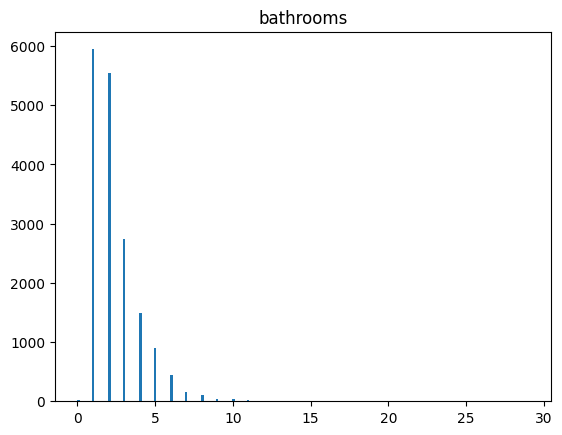

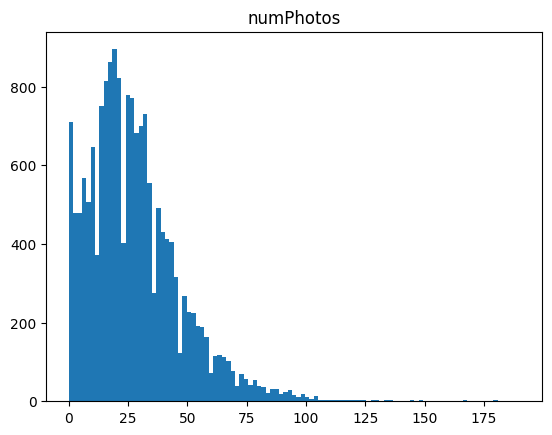

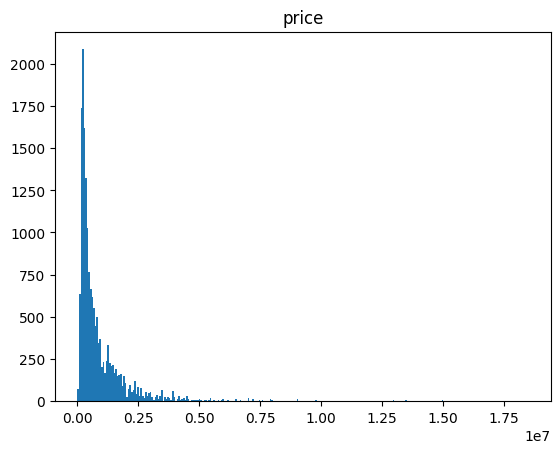

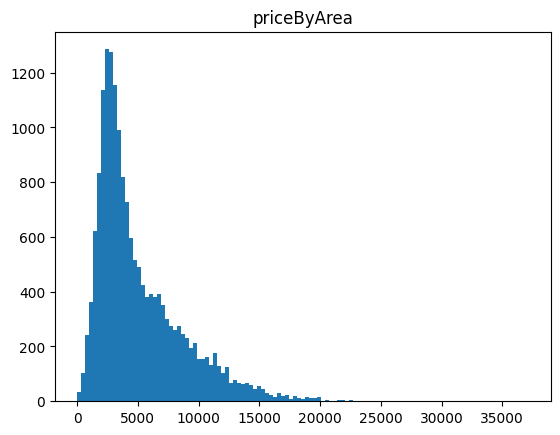

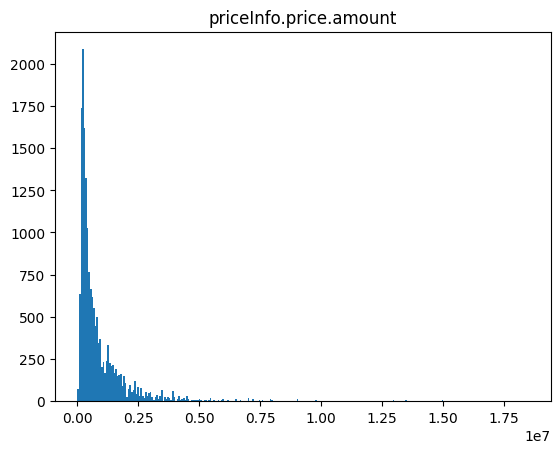

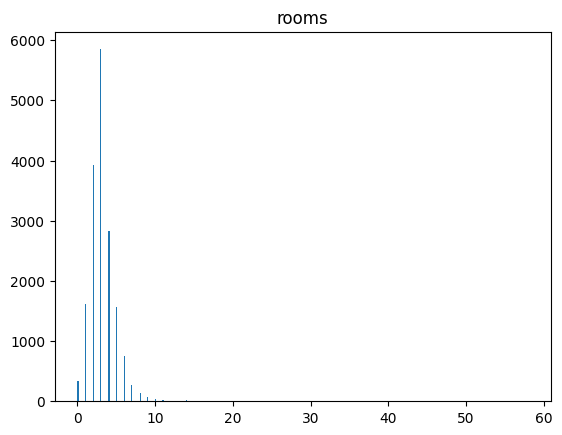

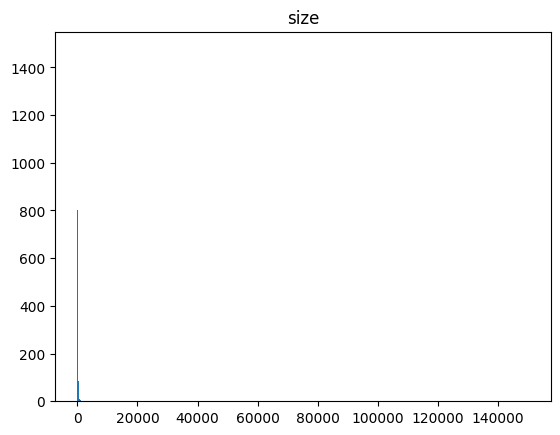

In [60]:
def graph_hist(series, bins="auto"):
    plt.hist(series, bins=bins)
    plt.title(series.name)
    plt.show()

for var in variables_num:
    graph_hist(df_copy[var])

## Variables categoricas

In [45]:
variables_cat = df_copy.select_dtypes(include=['object', 'category']).columns.tolist()
variables_cat = remove_repeated(variables_cat, variables_nulas)
variables_cat

['detailedType.typology', 'municipality', 'propertyType']

## Sumatorio variables

In [61]:
sum_var = 0
variables = [variables_nulas, variable_bool, variables_num, variables_cat]
for var in variables:
    sum_var += len(var)
print(column_tot==sum_var)
print(f"Columnas totales: {column_tot}")
print(f"Variables: {sum_var}")

True
Columnas totales: 33
Variables: 33


# Recuperación de variables nulas

parkingSpace.isParkingSpaceIncludedInPrice  False  True   All
parkingSpace.parkingSpacePrice                               
False                                           5  7570  7575
True                                          269     0   269
All                                           274  7570  7844


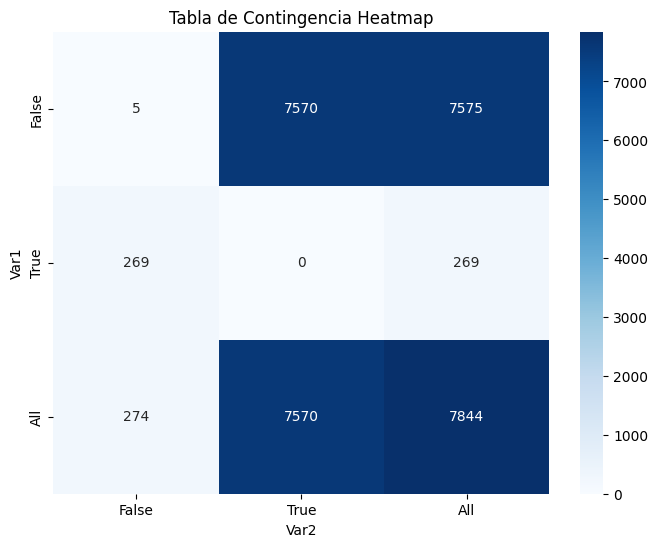

parkingSpace.isParkingSpaceIncludedInPrice         False  True   All
priceInfo.price.priceDropInfo.priceDropPercentage                   
False                                                236  6964  7200
True                                                  38   606   644
All                                                  274  7570  7844


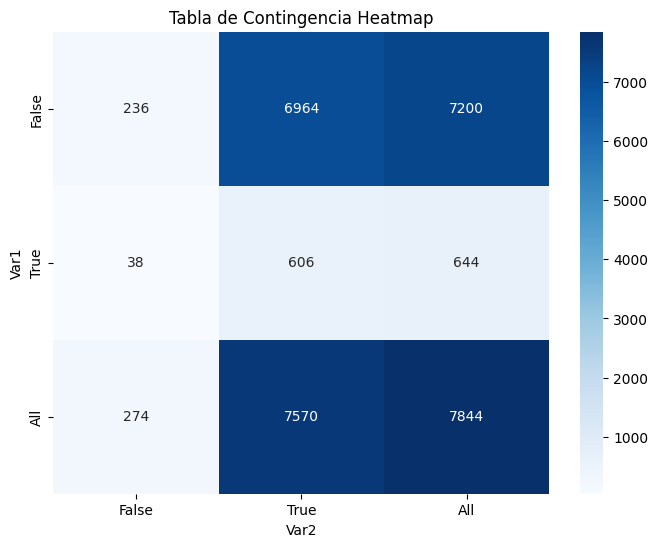

parkingSpace.isParkingSpaceIncludedInPrice  False  True   All
priceInfo.price.priceDropInfo.formerPrice                    
False                                         236  6964  7200
True                                           38   606   644
All                                           274  7570  7844


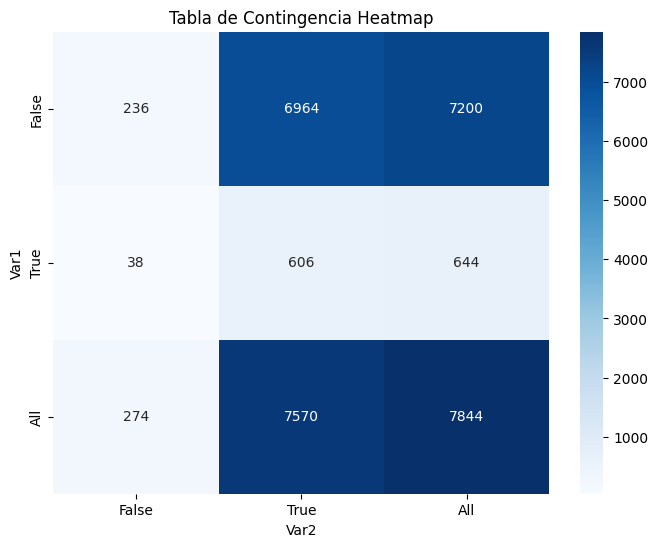

parkingSpace.isParkingSpaceIncludedInPrice    False  True   All
priceInfo.price.priceDropInfo.priceDropValue                   
False                                           236  6964  7200
True                                             38   606   644
All                                             274  7570  7844


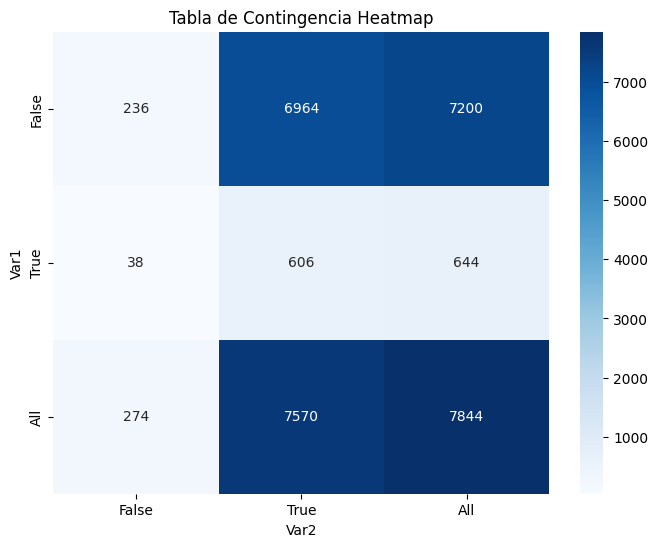

In [ ]:

df_nulos = df_copy[[
    "parkingSpace.parkingSpacePrice",
    "priceInfo.price.priceDropInfo.priceDropPercentage",
    "priceInfo.price.priceDropInfo.formerPrice",
    "priceInfo.price.priceDropInfo.priceDropValue"]].notna()


def tabla_contingencia(series1, series2):
    # Creamos la tabla de contingencia
    tabla_contingencia = pd.crosstab(series1, series2)

    # Dibujamos el heatmap de la tabla de contingencia para aquellos que tengan un valor 
    # significativo de dependencia
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(tabla_contingencia, annot=True, fmt='g', cmap='Blues')
    plt.title('Tabla de Contingencia Heatmap')
    plt.xlabel('Var2')
    plt.ylabel('Var1')
    plt.show()


for col in df_nulos.columns:

    series1 = df_nulos[col]
    series2 = df_copy["parkingSpace.isParkingSpaceIncludedInPrice"]

    tabla_contingencia(series1, series2)